# Import Libraries

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl


## Load Dataset

In [74]:
df = pd.read_csv('cars.csv')

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Data Understanding

In [79]:
cdf = df[['brand' , 'model_year' , 'milage' , 'fuel_type' , 'transmission' , 'price']]

cdf.head(9)

,brand,model_year,milage,fuel_type,transmission,price
0,Ford,2013,51000.0,E85 Flex Fuel,6-Speed A/T,10300.0
1,Hyundai,2021,34742.0,Gasoline,8-Speed Automatic,38005.0
2,Lexus,2022,22372.0,Gasoline,Automatic,54598.0
3,INFINITI,2015,88900.0,Hybrid,7-Speed A/T,15500.0
4,Audi,2021,9835.0,Gasoline,8-Speed Automatic,34999.0
5,Acura,2016,136397.0,Gasoline,F,14798.0
6,Audi,2017,84000.0,Gasoline,6-Speed A/T,31000.0
7,BMW,2001,242000.0,Gasoline,A/T,7300.0
8,Lexus,2021,23436.0,Gasoline,6-Speed A/T,41927.0


## Data Cleaning

In [80]:
df['milage'] = df['milage'].str.replace(',' , '').str.replace('mi.' , '').astype(float)

df['price'] = df['price'].str.replace('$' , '').str.replace(',' , '').astype(float)

des_price = cdf['price'].describe()
des_milage = cdf['milage'].describe()
print(des_price)
print(des_milage)
cdf_plot = cdf[cdf['price'] < 200000]

AttributeError: Can only use .str accessor with string values, not floating

## Exploratory Data Analysis

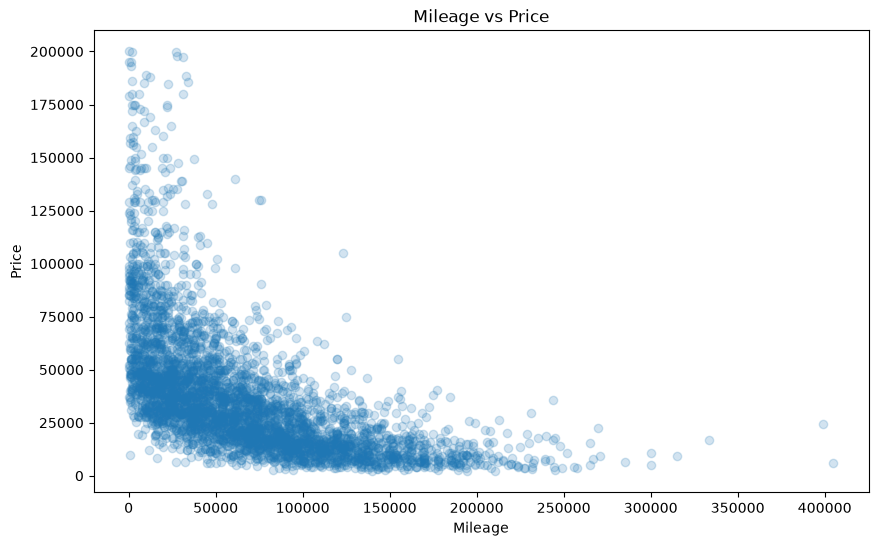

In [81]:
plt.figure(figsize=(10, 6))

plt.scatter(cdf_plot["milage"], cdf_plot["price"], alpha=0.2)

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")

plt.show()

In [82]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

In [83]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

train_x = np.asanyarray(train[['milage']])
train_y = np.asanyarray(train[['price']])

test_x = np.asanyarray(test[['milage']])
test_y = np.asanyarray(test[['price']])

print(train_x[:3])

poly = PolynomialFeatures(degree = 3)

train_x_poly = poly.fit_transform(train_x)
train_x_poly

[[51000.]
 [34742.]
 [88900.]]


array([[1.00000000e+00, 5.10000000e+04, 2.60100000e+09, 1.32651000e+14],
       [1.00000000e+00, 3.47420000e+04, 1.20700656e+09, 4.19338220e+13],
       [1.00000000e+00, 8.89000000e+04, 7.90321000e+09, 7.02595369e+14],
       ...,
       [1.00000000e+00, 1.09000000e+04, 1.18810000e+08, 1.29502900e+12],
       [1.00000000e+00, 2.11600000e+03, 4.47745600e+06, 9.47429690e+09],
       [1.00000000e+00, 4.30000000e+04, 1.84900000e+09, 7.95070000e+13]],
      shape=(3218, 4))